# Distribution network inventory and service level optimization

**Use Case C | Supply Chain**  
The notebook reads the synthetic CSV, estimates a safety stock and weekly review order-up-to point for each DC–SKU, compares policies on a chronological holdout, and writes the project tables, chart, and stakeholder memo. Run all cells from the project root or from `notebook_or_src/`.

**Interpretation of service:** fill rate = units served ÷ units requested. Stockout-week rate is reported separately. Inventory is in units because item costs are unavailable.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_LEFT
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle

ROOT = Path.cwd()
if not (ROOT / "data" / "supply_chain_dataset.csv").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "supply_chain_dataset.csv"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
RNG = np.random.default_rng(20260925)
pd.set_option("display.max_columns", 30)


## 1. Data audit and chronological split

The first 52 weeks are used for policy estimation, weeks 53–78 for choosing one network-wide service setting, and weeks 79–104 for the final backtest. No holdout demand or lead time enters policy selection.

In [2]:
df = pd.read_csv(DATA, parse_dates=["week_start_date"]).sort_values(["dc_id", "sku", "week_start_date"])
required = {"week_start_date", "dc_id", "region", "sku", "weekly_demand_units", "supplier_lead_time_days", "opening_inventory_units", "closing_inventory_units", "stockout_flag", "units_short", "replenishment_qty_units", "current_safety_stock_units", "service_level_target_pct"}
assert required.issubset(df.columns)
assert not df[list(required)].isna().any().any()
assert not df.duplicated(["week_start_date", "dc_id", "sku"]).any()
weeks = pd.DatetimeIndex(sorted(df.week_start_date.unique()))
assert len(weeks) == 104 and df.groupby(["dc_id", "sku"]).size().eq(104).all()
assert df.groupby(["dc_id", "sku"]).current_safety_stock_units.nunique().eq(1).all()
assert df.service_level_target_pct.eq(95).all()
week_number = {date: i for i, date in enumerate(weeks)}
df["week_number"] = df.week_start_date.map(week_number)
train = df[df.week_number < 52]
validation = df[(df.week_number >= 52) & (df.week_number < 78)]
holdout = df[df.week_number >= 78]
print(f"{len(df):,} rows | {df.dc_id.nunique()} DCs | {df.sku.nunique()} SKUs | {len(weeks)} weeks")
print(f"Train: {weeks[0].date()}–{weeks[51].date()}; validation: {weeks[52].date()}–{weeks[77].date()}; holdout: {weeks[78].date()}–{weeks[103].date()}")
print("Observed full-data fill rate:", round(1 - df.units_short.sum() / df.weekly_demand_units.sum(), 4))


9,360 rows | 6 DCs | 15 SKUs | 104 weeks
Train: 2024-09-02–2025-08-25; validation: 2025-09-01–2026-02-23; holdout: 2026-03-02–2026-08-24
Observed full-data fill rate: 0.9732


## 2. Current-state diagnosis

Observed outcomes describe what happened under the actual operation. The full historical ordering logic is not recorded, so these outcomes are a diagnostic rather than the controlled policy comparison below.

In [3]:
def observed_summary(frame, keys):
    x = frame.groupby(keys).agg(demand=("weekly_demand_units", "sum"), units_short=("units_short", "sum"), stockout_weeks=("stockout_flag", "sum"), rows=("stockout_flag", "size"), mean_closing=("closing_inventory_units", "mean"), mean_lead_days=("supplier_lead_time_days", "mean"))
    x["fill_rate"] = 1 - x.units_short / x.demand
    x["stockout_week_rate"] = x.stockout_weeks / x.rows
    return x.sort_values("units_short", ascending=False)

observed_dc = observed_summary(holdout, ["dc_id"])
observed_pair = observed_summary(holdout, ["dc_id", "sku"])
display(observed_dc.round(3))
display(observed_pair.head(10).round(3))


,demand,units_short,stockout_weeks,rows,mean_closing,mean_lead_days,fill_rate,stockout_week_rate
dc_id,,,,,,,,
DC-06,143853,8306,70,390,641.956,7.690,0.942,0.179
DC-02,127716,5554,49,390,608.769,9.595,0.957,0.126
DC-01,123302,4317,44,390,542.236,6.997,0.965,0.113
DC-05,121533,4209,47,390,585.972,11.233,0.965,0.121
DC-03,119992,3492,59,390,601.259,6.292,0.971,0.151
DC-04,128636,3307,39,390,642.105,8.439,0.974,0.100


,,demand,units_short,stockout_weeks,rows,mean_closing,mean_lead_days,fill_rate,stockout_week_rate
dc_id,sku,,,,,,,,
DC-06,SKU-SKU-201,18564,2136,7,26,939.385,7.400,0.885,0.269
DC-02,SKU-SKU-201,14241,2039,7,26,924.654,9.019,0.857,0.269
DC-06,SKU-SKU-303,17726,1861,10,26,859.462,7.627,0.895,0.385
DC-01,SKU-SKU-303,17448,1793,10,26,804.885,7.112,0.897,0.385
DC-05,SKU-SKU-103,15173,1336,7,26,870.308,11.254,0.912,0.269
DC-06,SKU-SKU-202,11171,1186,12,26,602.846,7.981,0.894,0.462
DC-02,SKU-SKU-202,15218,888,5,26,982.385,10.081,0.942,0.192
DC-03,SKU-SKU-403,7028,888,13,26,344.462,6.312,0.874,0.500
DC-04,SKU-SKU-103,14940,875,8,26,725.077,9.035,0.941,0.308


## 3. Model demand during the protection period

Orders are reviewed weekly. An order placed in week *t* arrives at the beginning of week *t + ceil(lead time ÷ 7)*. The protection period is one review week plus the lead-time weeks. For each pair, bootstrap 10,000 protection-period demand totals from its first 52 observed demand and lead-time values. This keeps the empirical variability and skew without assuming a normal distribution. Demand and lead time are sampled independently; the data does not establish a causal link between them.

The recommended order-up-to point is an empirical quantile of protection demand. Its safety stock is the amount above mean protection demand. The reconstructed current point is mean protection demand plus the recorded fixed safety stock. Both points use the same order and arrival mechanics in the backtest.

In [4]:
N_BOOT = 10_000
pair_data = {}
policy_stats = []
for key, group in df.groupby(["dc_id", "sku"], sort=True):
    group = group.sort_values("week_number")
    demand_train = group.iloc[:52].weekly_demand_units.to_numpy(dtype=int)
    lead_train = group.iloc[:52].supplier_lead_time_days.to_numpy(dtype=float)
    lead_weeks = np.maximum(1, np.ceil(lead_train / 7).astype(int))
    sampled_lead = RNG.choice(lead_weeks, N_BOOT)
    protection_weeks = 1 + sampled_lead
    sampled_demand = RNG.choice(demand_train, (N_BOOT, int(protection_weeks.max())))
    protection_demand = (sampled_demand * (np.arange(sampled_demand.shape[1])[None, :] < protection_weeks[:, None])).sum(axis=1)
    mean_protection = float(demand_train.mean() * (1 + lead_weeks.mean()))
    fixed_ss = int(group.current_safety_stock_units.iloc[0])
    pair_data[key] = {"frame": group, "samples": protection_demand, "mean_protection": mean_protection, "fixed_ss": fixed_ss}
    policy_stats.append({"dc_id": key[0], "sku": key[1], "mean_weekly_demand": demand_train.mean(), "sd_weekly_demand": demand_train.std(ddof=1), "mean_lead_days": lead_train.mean(), "sd_lead_days": lead_train.std(ddof=1), "mean_protection_demand": mean_protection, "current_safety_stock": fixed_ss})
policy_stats = pd.DataFrame(policy_stats)
display(policy_stats.head().round(1))


,dc_id,sku,mean_weekly_demand,sd_weekly_demand,mean_lead_days,sd_lead_days,mean_protection_demand,current_safety_stock
0,DC-01,SKU-501,181.5,67.1,7.0,0.8,453.8,360
1,DC-01,SKU-502,312.3,62.6,7.0,0.8,768.7,626
2,DC-01,SKU-503,270.4,61.9,6.8,1.0,644.7,552
3,DC-01,SKU-SKU-101,161.2,80.1,6.7,0.9,381.2,321
4,DC-01,SKU-SKU-102,148.2,94.9,7.2,1.0,376.2,307


## 4. Comparable weekly-review simulation

Each simulation starts 13 weeks before its score window, with on-hand stock set to that policy's point. Warm-up weeks are excluded from metrics. At each week's start, scheduled orders arrive, an order raises inventory position toward the point, and then the week's demand is served. Unmet demand is lost, not backordered. This is a controlled policy scenario, not a reconstruction of actual receipts. The actual realized lead-time sequence is used only as an exogenous scenario during each evaluation window.

In [5]:
def simulate(group, point, score_start, score_end, warmup=13):
    rows = group.sort_values("week_number").reset_index(drop=True)
    first = score_start - warmup
    on_hand = int(point)
    pipeline = {}
    records = []
    for t in range(first, score_end):
        on_hand += pipeline.pop(t, 0)
        opening = on_hand
        position = on_hand + sum(pipeline.values())
        order = max(0, int(point) - position)
        if order:
            lead_weeks = max(1, math.ceil(float(rows.loc[t, "supplier_lead_time_days"]) / 7))
            arrival = t + lead_weeks
            pipeline[arrival] = pipeline.get(arrival, 0) + order
        demand = int(rows.loc[t, "weekly_demand_units"])
        served = min(on_hand, demand)
        on_hand -= served
        if t >= score_start:
            records.append({"week_number": t, "demand": demand, "served": served, "short": demand - served, "stockout": int(served < demand), "avg_on_hand": (opening + on_hand) / 2, "end_on_hand": on_hand})
    return pd.DataFrame(records)

def evaluate(points, score_start, score_end):
    pieces = []
    for key, info in pair_data.items():
        run = simulate(info["frame"], points[key], score_start, score_end)
        run["dc_id"], run["sku"] = key
        pieces.append(run)
    return pd.concat(pieces, ignore_index=True)

def metrics(run):
    return {"fill_rate": run.served.sum() / run.demand.sum(), "stockout_week_rate": run.stockout.mean(), "mean_on_hand_units": run.avg_on_hand.sum() / (run.week_number.nunique() * len(pair_data)), "units_short": int(run.short.sum())}

current_points = {key: math.ceil(info["mean_protection"] + info["fixed_ss"]) for key, info in pair_data.items()}


## 5. Validate the company service setting

Try candidate protection-demand quantiles from 70% to 99% to show the service and inventory curve. Use the company's 95% standard as the protection-demand quantile for the recommended policy, and check its achieved fill rate on validation. A lower quantile can appear cheaper in validation but may fail when demand shifts. The quantile is an ordering parameter, not itself a guaranteed fill rate.

In [6]:
quantiles = [0.70, 0.75, 0.80, 0.85, 0.90, 0.92, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
validation_rows = []
for q in quantiles:
    points = {key: math.ceil(np.quantile(info["samples"], q)) for key, info in pair_data.items()}
    result = metrics(evaluate(points, 52, 78))
    validation_rows.append({"quantile": q, **result})
validation_table = pd.DataFrame(validation_rows)
chosen_q = 0.95
selected = validation_table.set_index("quantile").loc[chosen_q]
recommended_points = {key: math.ceil(np.quantile(info["samples"], chosen_q)) for key, info in pair_data.items()}
display(validation_table.round(4))
print("Selected quantile:", chosen_q, "| validation fill:", round(float(selected.fill_rate), 4))


,quantile,fill_rate,stockout_week_rate,mean_on_hand_units,units_short
0,0.70,0.9223,0.1825,367.4673,54287
1,0.75,0.9366,0.1517,396.2280,44243
2,0.80,0.9506,0.1274,430.1848,34527
3,0.85,0.9638,0.0983,471.9250,25269
4,0.90,0.9762,0.0641,528.2654,16610
5,0.92,0.9809,0.0564,557.4872,13324
6,0.94,0.9859,0.0440,594.7968,9871
7,0.95,0.9882,0.0363,617.3628,8218
8,0.96,0.9906,0.0286,644.2096,6571
9,0.97,0.9928,0.0222,677.1368,5002


Selected quantile: 0.95 | validation fill: 0.9882


## 6. Chronological holdout backtest

The two modeled policies share the same demand, lead times, order timing, and warm-up. This isolates the effect of changing the point. The observed current operation is shown separately because its receipt and order rules may differ. A more aggressive 80th-percentile candidate initially met 95% fill on validation but failed the holdout target. The 95th-percentile recommendation is a revision after that inspection, so its holdout result is exploratory and must be confirmed in a live pilot.

In [7]:
current_run = evaluate(current_points, 78, 104)
recommended_run = evaluate(recommended_points, 78, 104)
comparison = pd.DataFrame([{"policy": "Current fixed SS, modeled", **metrics(current_run)}, {"policy": "Recommended, modeled", **metrics(recommended_run)}])
observed = {"policy": "Actual historical operation", "fill_rate": 1 - holdout.units_short.sum() / holdout.weekly_demand_units.sum(), "stockout_week_rate": holdout.stockout_flag.mean(), "mean_on_hand_units": holdout.closing_inventory_units.mean(), "units_short": int(holdout.units_short.sum())}
display(comparison.round(4))
display(pd.DataFrame([observed]).round(4))

policy = policy_stats.copy()
policy["current_reorder_point"] = [current_points[(r.dc_id, r.sku)] for r in policy.itertuples()]
policy["recommended_reorder_point"] = [recommended_points[(r.dc_id, r.sku)] for r in policy.itertuples()]
policy["recommended_safety_stock"] = np.maximum(0, np.ceil(policy.recommended_reorder_point - policy.mean_protection_demand)).astype(int)
policy["safety_stock_change"] = policy.recommended_safety_stock - policy.current_safety_stock
policy.to_csv(OUT / "dc_sku_recommendations.csv", index=False)
comparison.to_csv(OUT / "holdout_policy_comparison.csv", index=False)
validation_table.to_csv(OUT / "validation_tradeoff.csv", index=False)
display(policy.sort_values("safety_stock_change", ascending=False).head(12).round(1))


,policy,fill_rate,stockout_week_rate,mean_on_hand_units,units_short
0,"Current fixed SS, modeled",0.9943,0.0145,747.5147,4379
1,"Recommended, modeled",0.9786,0.0650,548.5218,16346


,policy,fill_rate,stockout_week_rate,mean_on_hand_units,units_short
0,Actual historical operation,0.9619,0.1316,603.7162,29185


,dc_id,sku,mean_weekly_demand,sd_weekly_demand,mean_lead_days,sd_lead_days,mean_protection_demand,current_safety_stock,current_reorder_point,recommended_reorder_point,recommended_safety_stock,safety_stock_change
6,DC-01,SKU-SKU-201,413.2,248.4,6.9,1.0,1040.8,731,1772,1821,781,50
79,DC-06,SKU-SKU-102,192.6,122.8,7.7,1.2,522.1,368,891,903,381,13
4,DC-01,SKU-SKU-102,148.2,94.9,7.2,1.0,376.2,307,684,676,300,-7
66,DC-05,SKU-SKU-201,345.4,213.0,10.5,2.9,1016.4,744,1761,1733,717,-27
54,DC-04,SKU-SKU-301,279.0,165.1,8.5,2.3,772.6,534,1307,1273,501,-33
19,DC-02,SKU-SKU-102,180.5,90.8,10.1,2.3,534.4,338,873,836,302,-36
64,DC-05,SKU-SKU-102,151.8,73.4,11.3,3.4,467.0,297,764,725,259,-38
40,DC-03,SKU-SKU-302,162.8,90.0,6.3,0.7,350.7,297,648,592,242,-55
63,DC-05,SKU-SKU-101,176.2,85.9,11.1,2.9,535.2,342,878,820,285,-57
85,DC-06,SKU-SKU-302,152.5,74.4,8.0,1.3,425.2,285,711,651,226,-59


In [8]:
def pair_metrics(run):
    x = run.groupby(["dc_id", "sku"]).agg(demand=("demand", "sum"), served=("served", "sum"), units_short=("short", "sum"), stockout_week_rate=("stockout", "mean"), mean_on_hand_units=("avg_on_hand", "mean"))
    x["fill_rate"] = x.served / x.demand
    return x

before_pair = pair_metrics(current_run)
after_pair = pair_metrics(recommended_run)
pair_comparison = before_pair[["fill_rate", "units_short", "mean_on_hand_units"]].add_prefix("current_").join(after_pair[["fill_rate", "units_short", "mean_on_hand_units"]].add_prefix("recommended_"))
pair_comparison.to_csv(OUT / "holdout_dc_sku_comparison.csv")
by_dc = []
for label, run in [("Current fixed SS, modeled", current_run), ("Recommended, modeled", recommended_run)]:
    for dc, g in run.groupby("dc_id"):
        by_dc.append({"policy": label, "dc_id": dc, "fill_rate": g.served.sum() / g.demand.sum(), "stockout_week_rate": g.stockout.mean(), "mean_on_hand_units": g.avg_on_hand.mean(), "units_short": g.short.sum()})
by_dc = pd.DataFrame(by_dc)
by_dc.to_csv(OUT / "holdout_by_dc.csv", index=False)
display(by_dc.pivot(index="dc_id", columns="policy", values=["fill_rate", "mean_on_hand_units"]).round(3))


fill_rate                       \
policy Current fixed SS, modeled Recommended, modeled   
dc_id                                                   
DC-01                      0.992                0.977   
DC-02                      0.996                0.977   
DC-03                      0.996                0.980   
DC-04                      0.998                0.984   
DC-05                      0.993                0.974   
DC-06                      0.990                0.979   

              mean_on_hand_units                       
policy Current fixed SS, modeled Recommended, modeled  
dc_id                                                  
DC-01                    707.773              535.233  
DC-02                    738.108              505.462  
DC-03                    726.551              523.371  
DC-04                    748.737              543.290  
DC-05                    735.177              571.777  
DC-06                    828.742              611.999

## 7. Leadership view and operating rules

The chart compares the selected policy with the modeled current policy. All inventory figures are average physical on-hand units per DC–SKU, not a monetary working-capital estimate. A procurement cost file would be needed to convert units to currency.

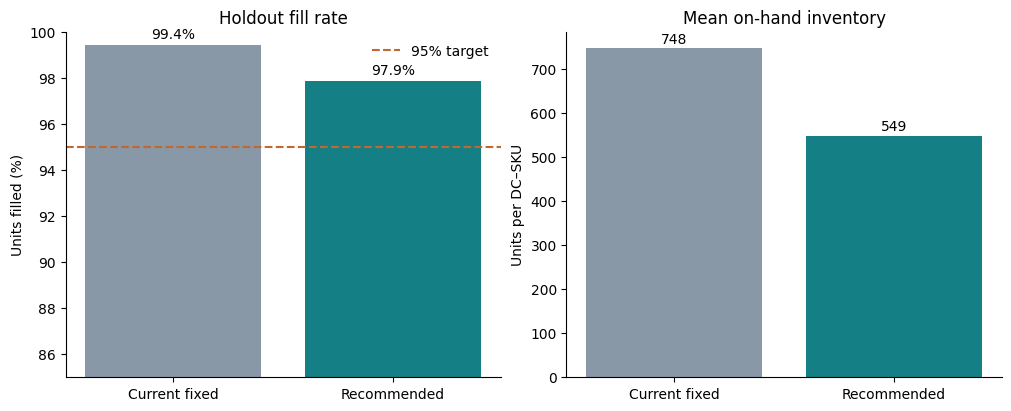

Holdout change: -1.56 percentage points fill, -26.6% mean on-hand units per pair.


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
labels = ["Current fixed", "Recommended"]
fill = comparison.fill_rate.to_numpy() * 100
stock = comparison.mean_on_hand_units.to_numpy()
bars = ax[0].bar(labels, fill, color=["#8898a7", "#157f86"])
ax[0].axhline(95, color="#c26730", linestyle="--", linewidth=1.5, label="95% target")
ax[0].set(ylabel="Units filled (%)", title="Holdout fill rate", ylim=(min(85, fill.min() - 2), 100))
ax[0].legend(frameon=False)
for bar, value in zip(bars, fill): ax[0].text(bar.get_x() + bar.get_width() / 2, value + 0.3, f"{value:.1f}%", ha="center")
bars = ax[1].bar(labels, stock, color=["#8898a7", "#157f86"])
ax[1].set(ylabel="Units per DC–SKU", title="Mean on-hand inventory")
for bar, value in zip(bars, stock): ax[1].text(bar.get_x() + bar.get_width() / 2, value + max(stock) * 0.015, f"{value:,.0f}", ha="center")
for a in ax: a.spines[["top", "right"]].set_visible(False)
fig.savefig(OUT / "holdout_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

delta_fill = (comparison.loc[1, "fill_rate"] - comparison.loc[0, "fill_rate"]) * 100
delta_inventory = (comparison.loc[1, "mean_on_hand_units"] / comparison.loc[0, "mean_on_hand_units"] - 1) * 100
print(f"Holdout change: {delta_fill:+.2f} percentage points fill, {delta_inventory:+.1f}% mean on-hand units per pair.")


**Operating recommendation.** Review inventory position every Monday for each DC–SKU. Order enough to reach the recommended point after considering open purchase orders. Recalculate monthly from the latest 52 weeks of demand and lead times; review exceptional promotions, new items, and supplier disruptions with planners. Track unit fill rate, stockout weeks, and on-hand inventory by DC–SKU. Escalate pairs below 95% fill and retune the point before rolling out broadly. A pilot should verify actual order timing, lead-time definitions, supplier minimums, and holding costs.

**Limits.** Weekly data cannot identify within-week stockouts. Lead time and demand may be correlated or seasonal. The current policy is reconstructed from the fixed safety stock and a common review rule because the exact current ordering logic is absent. Backtest results are modeled scenarios, not causal estimates. The observed holdout line gives a separate reality check. The warm-up and starting-stock choice may affect the first few scored weeks, so operational pilot results should supersede modeled estimates.

## 8. Generate the stakeholder memo

This cell writes a local one-page PDF using the figures above. It is deliberately short and avoids modeling detail that the Head of Supply Chain does not need.

In [10]:
pdf_path = ROOT / "business_memo.pdf"
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="MemoTitle", parent=styles["Title"], fontName="Helvetica-Bold", fontSize=15, leading=18, textColor=colors.HexColor("#18354a"), spaceAfter=10))
styles.add(ParagraphStyle(name="MemoBody", parent=styles["BodyText"], fontName="Helvetica", fontSize=9.4, leading=13.5, spaceAfter=9))
styles.add(ParagraphStyle(name="MemoSmall", parent=styles["BodyText"], fontName="Helvetica", fontSize=8.2, leading=11, spaceAfter=7))
doc = SimpleDocTemplate(str(pdf_path), pagesize=A4, rightMargin=45, leftMargin=45, topMargin=38, bottomMargin=38)
story = [Paragraph("Inventory policy recommendation", styles["MemoTitle"]), Paragraph("To: Head of Supply Chain &nbsp;&nbsp; | &nbsp;&nbsp; Subject: DC–SKU safety stock and service", styles["MemoSmall"])]
priority = observed_dc.index[:2].tolist()
top_one, top_two = priority
for text in [
    f"<b>Decision requested.</b> Pilot DC–SKU specific reorder points in {top_one} and {top_two}, then extend to the network if the 95% unit fill-rate target holds in live operation. Keep a weekly review rhythm and refresh the points monthly.",
    f"<b>Why change.</b> Each DC–SKU keeps its fixed stock setting for two years, even as demand and supplier lead times move. In the final 26 weeks, {top_one} lost {int(observed_dc.loc[top_one, 'units_short']):,} units and {top_two} lost {int(observed_dc.loc[top_two, 'units_short']):,} units. {top_one} needs attention for the largest shortfall; {top_two} is the next largest shortfall. A fixed cushion places cash in some items while leaving other items exposed.",
    "<b>Trade-off.</b> Protect at least 95% of requested units while keeping average physical inventory as low as the service goal permits. More stock can improve service, but it ties up working capital. Item costs are not supplied, so the table reports inventory units rather than currency."
]: story.append(Paragraph(text, styles["MemoBody"]))
table_data = [["Final 26 weeks", "Modeled current", "Recommended"], ["Unit fill rate", f"{comparison.loc[0, 'fill_rate']:.1%}", f"{comparison.loc[1, 'fill_rate']:.1%}"], ["Stockout weeks", f"{comparison.loc[0, 'stockout_week_rate']:.1%}", f"{comparison.loc[1, 'stockout_week_rate']:.1%}"], ["Mean on-hand / DC–SKU", f"{comparison.loc[0, 'mean_on_hand_units']:,.0f}", f"{comparison.loc[1, 'mean_on_hand_units']:,.0f}"]]
table = Table(table_data, colWidths=[190, 125, 125])
table.setStyle(TableStyle([("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#18354a")), ("TEXTCOLOR", (0, 0), (-1, 0), colors.white), ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"), ("FONTSIZE", (0, 0), (-1, -1), 8.8), ("BOTTOMPADDING", (0, 0), (-1, -1), 7), ("TOPPADDING", (0, 0), (-1, -1), 7), ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.whitesmoke, colors.white]), ("LINEBELOW", (0, -1), (-1, -1), 0.5, colors.HexColor("#c5d3dc"))]))
story.extend([table, Spacer(1, 12)])
story.append(Paragraph(f"<b>How to operate.</b> Each Monday, compare on-hand plus open orders with the DC–SKU point. Order the difference. The point allows for measured demand swings and lead-time swings. Use the {chosen_q:.0%} protection-demand quantile and review service and inventory by pair every month, with planner overrides for promotions and supplier events.", styles["MemoBody"]))
story.append(Paragraph(f"<b>Decision limit.</b> The exact current order rule is absent, so before/after figures compare simulated policies. Actual recorded fill was {observed['fill_rate']:.1%}, below the modeled current result. An earlier leaner candidate missed the holdout target, and this revised result is exploratory. A live pilot and item costs should set the rollout and cash value.", styles["MemoSmall"]))
doc.build(story)
print(pdf_path.name)


business_memo.pdf
